In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:/Users/paulo/Desktop/pythonAnalise/analise/projeto7/data/india_cancer_patients_2022_2025.csv', sep= ',')

df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


Fase 1: O Perfil do Paciente (Data Quality & Distribuição)

A primeira coisa que um analista de saúde faz é entender quem são os pacientes. Nós queremos saber se a idade influencia o tipo de câncer que a pessoa desenvolve.

•	A sua missão: Crie um gráfico que mostre a distribuição de Idade (Age) para cada Tipo de Câncer (Cancer_Type).

•	Dica Visual: Em vez de usar gráficos de barras (que mostram médias ou somas), pesquise sobre como criar um Boxplot (Gráfico de Caixa) no Seaborn. Ele é perfeito para mostrar a idade mínima, máxima, e onde a maioria dos pacientes se concentra!


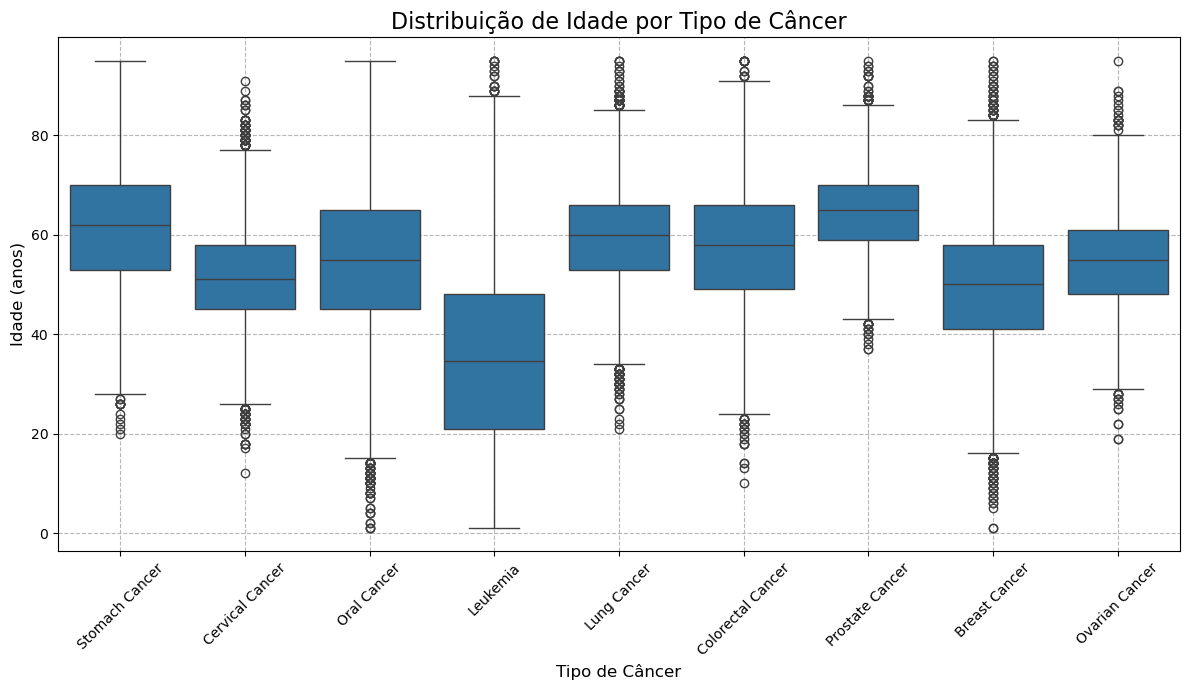

In [8]:
plt.figure(figsize=(12, 7))
GraficoDistrIdadeCancer = sns.boxplot(data=df, x="Cancer_Type", y="Age")

plt.title('Distribuição de Idade por Tipo de Câncer', fontsize=16)
plt.xlabel('Tipo de Câncer', fontsize=12)
plt.ylabel('Idade (anos)', fontsize=12)
plt.xticks(rotation=45) 

plt.grid(axis='x', linestyle='--', alpha=0.9)
plt.grid(axis='y', linestyle='--', alpha=0.9)


plt.tight_layout()

plt.savefig('GraficoDistrIdadeCancer.png') 

plt.show()



A rede hospitalar da Índia precisa saber para onde estão a ir os pacientes e que tratamentos estão a fazer.

•	A sua missão: Descubra qual é o Hospital (Hospital_Name) que atendeu mais pacientes no total. Depois, para esse hospital específico, crie um gráfico que mostre a contagem de pacientes por Tipo de Tratamento (Treatment_Type).


In [5]:
df_result = df['Hospital_Name'].value_counts().reset_index(name='QtAtendimentos')

df_result

,Hospital_Name,QtAtendimentos
0,Kidwai Memorial Institute of Oncology,10163
1,PGIMER,10108
2,Gujarat Cancer Research Institute,10105
3,Regional Cancer Centre,10030
4,Rajiv Gandhi Cancer Institute,10029
5,Adyar Cancer Institute,9997
6,Tata Memorial Hospital,9954
7,AIIMS,9909
8,Basavatarakam Indo American Cancer Hospital,9885
9,Tata Medical Center,9820


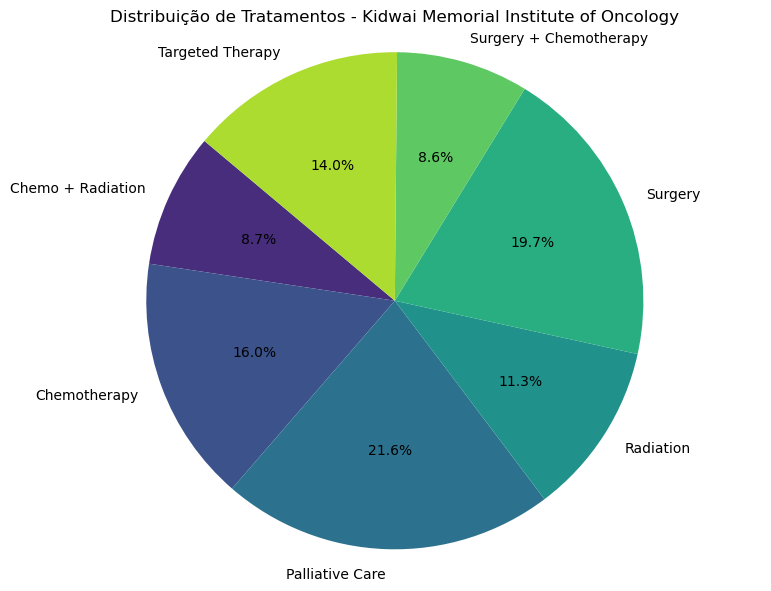

In [9]:
hospital_top1 = 'Kidwai Memorial Institute of Oncology' 
df_filtrado = df[df['Hospital_Name'] == hospital_top1]

contagem = df_filtrado.groupby('Treatment_Type')['Patient_ID'].nunique()


plt.figure(figsize=(8, 6))


plt.pie(contagem.values, 
        labels=contagem.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=sns.color_palette('viridis', len(contagem)))


plt.title(f'Distribuição de Tratamentos - {hospital_top1}')
plt.axis('equal')


plt.tight_layout()

plt.savefig('DistrTratamentos.png') 

plt.show()


•	A sua missão: Crie um gráfico que mostre a quantidade de casos de cada Cancer_Type separados por Gender (Masculino e Feminino).
                                                                                                             
•	Dica de Negócio: Pode usar um gráfico de barras agrupadas ou experimentar um Heatmap (Mapa de Calor) cruzando o Género com o Tipo de Câncer. E fique atento: como a base é gerada sinteticamente por IA, será que existe algum "bug" nos dados, como homens com câncer do colo do útero (Cervical Cancer)? Descubra!


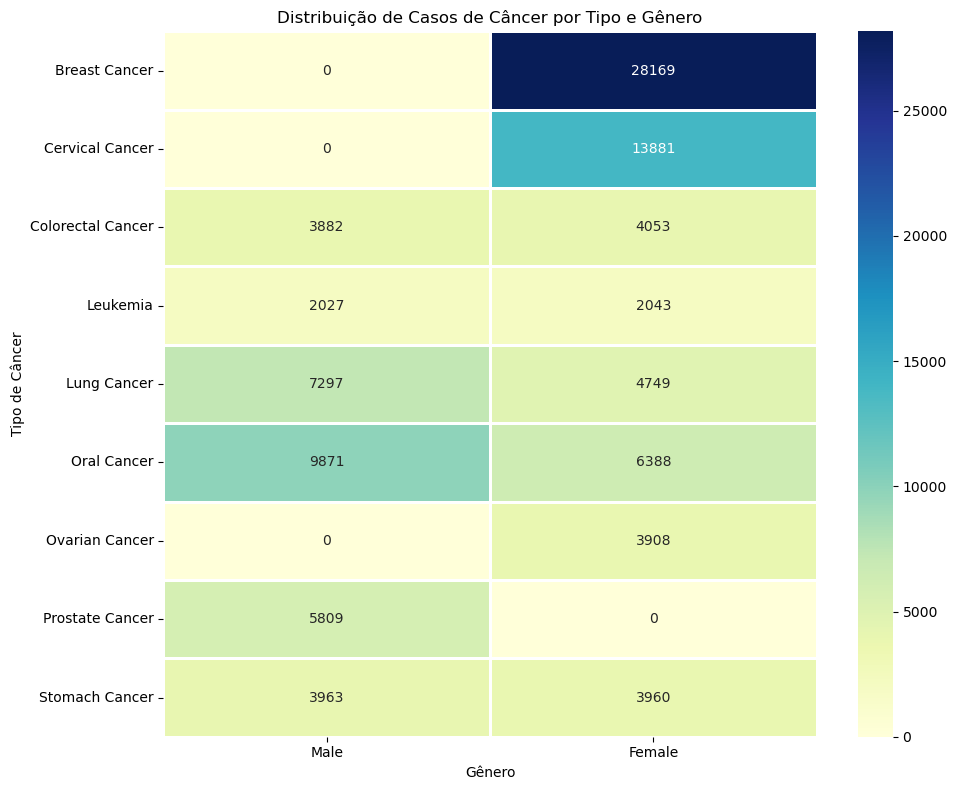

In [15]:
df_resultado = df.groupby(['Cancer_Type', 'Gender']).size().unstack(fill_value=0)

df_resultado = df_resultado[['Male', 'Female']] 


plt.figure(figsize=(10, 8))
sns.heatmap(
    df_resultado,
    annot=True,          
    fmt="d",            
    cmap="YlGnBu",       
    square=False,        
    linewidths=1,       
    linecolor='white'    
)

plt.title("Distribuição de Casos de Câncer por Tipo e Gênero")
plt.xlabel("Gênero")
plt.ylabel("Tipo de Câncer")

plt.tight_layout()

plt.savefig('CancerPorGenero.png') 

plt.show()


A hipótese médica número um é: "Quanto mais cedo o câncer é descoberto (Estágio I), mais tempo o paciente sobrevive". Será que os nossos dados provam isso?

•	A sua missão: Calcule a média de Meses de Sobrevivência (Survival_Months) agrupada pelo Estágio (Stage). Crie um gráfico ordenado do Estágio I ao Estágio IV para vermos visualmente se a linha de sobrevivência realmente cai conforme o estágio avança.


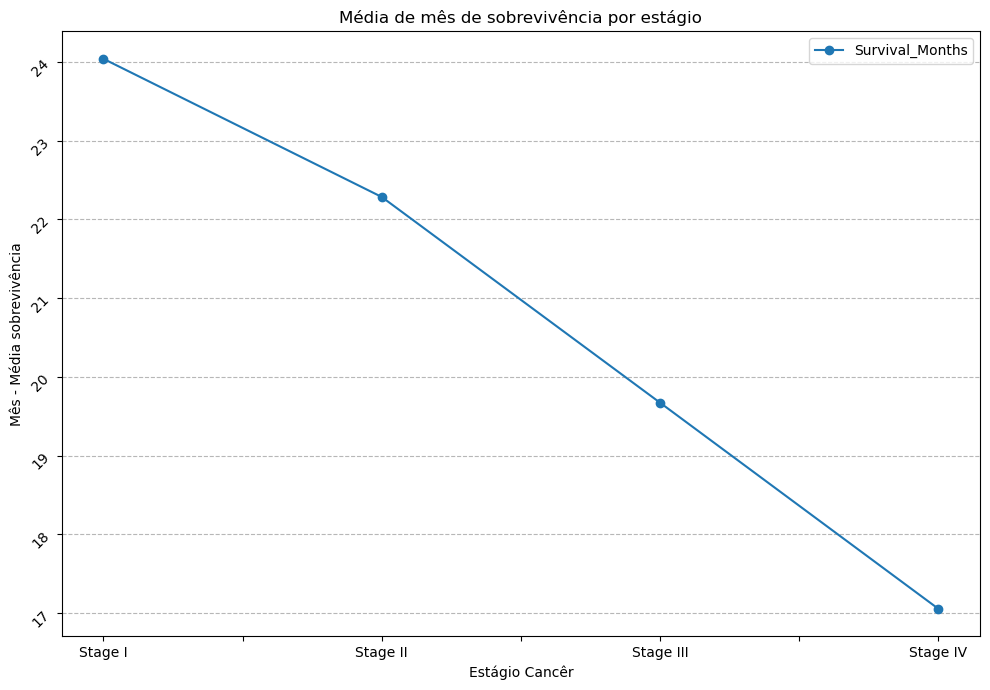

In [16]:
media =  df.groupby('Stage')['Survival_Months'].mean().reset_index()



media.plot(x='Stage',
           y='Survival_Months',
            kind='line',
           ylabel='Mês - Média sobrevivência',
           xlabel='Estágio Cancêr',
           marker='o',
           title='Média de mês de sobrevivência por estágio',
           figsize=(10, 7)
          )



plt.yticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.9)

plt.tight_layout()
plt.savefig('MediaDeSobr.png') 

plt.show() 


•	A sua missão: Agrupe os dados por Tipo de Câncer (Cancer_Type) e Tipo de Tratamento (Treatment_Type). Para cada combinação, você deve calcular:

1.	O total de pacientes atendidos.

2.	A média de meses de sobrevivência.

3.	(Desafio de Sênior): A Taxa de Sucesso (%), ou seja, qual a percentagem desses pacientes que têm o Status igual a 'Alive' (Vivo).


In [19]:
df['is_alive'] = (df['Status'] == 'Alive').astype(int)


resumo = df.groupby(['Cancer_Type', 'Treatment_Type']).agg(
    Total_Pacientes=('Patient_ID', 'count'),                        
    Media_Sobrevivencia_Meses=('Survival_Months', 'mean'),          
    Taxa_Sucesso_Perc=('is_alive', lambda x: x.mean() * 100)        
).reset_index()

resumo['Media_Sobrevivencia_Meses'] = resumo['Media_Sobrevivencia_Meses'].round(2)
resumo['Taxa_Sucesso_Perc'] = resumo['Taxa_Sucesso_Perc'].round(2)


resumo.head(10)

resumo.to_csv('relatorio_eficacia_tratamentos.csv', index=False, sep=';')

,Cancer_Type,Treatment_Type,Total_Pacientes,Media_Sobrevivencia_Meses,Taxa_Sucesso_Perc
0,Breast Cancer,Chemo + Radiation,2441,22.55,52.23
1,Breast Cancer,Chemotherapy,4508,20.51,35.20
2,Breast Cancer,Palliative Care,5899,19.81,31.73
3,Breast Cancer,Radiation,3233,23.63,58.92
4,Breast Cancer,Surgery,5815,24.89,70.40
5,Breast Cancer,Surgery + Chemotherapy,2482,22.03,50.89
6,Breast Cancer,Targeted Therapy,3791,20.84,38.57
7,Cervical Cancer,Chemo + Radiation,1209,20.59,38.30
8,Cervical Cancer,Chemotherapy,2204,18.95,28.22
9,Cervical Cancer,Palliative Care,3002,18.41,23.38
